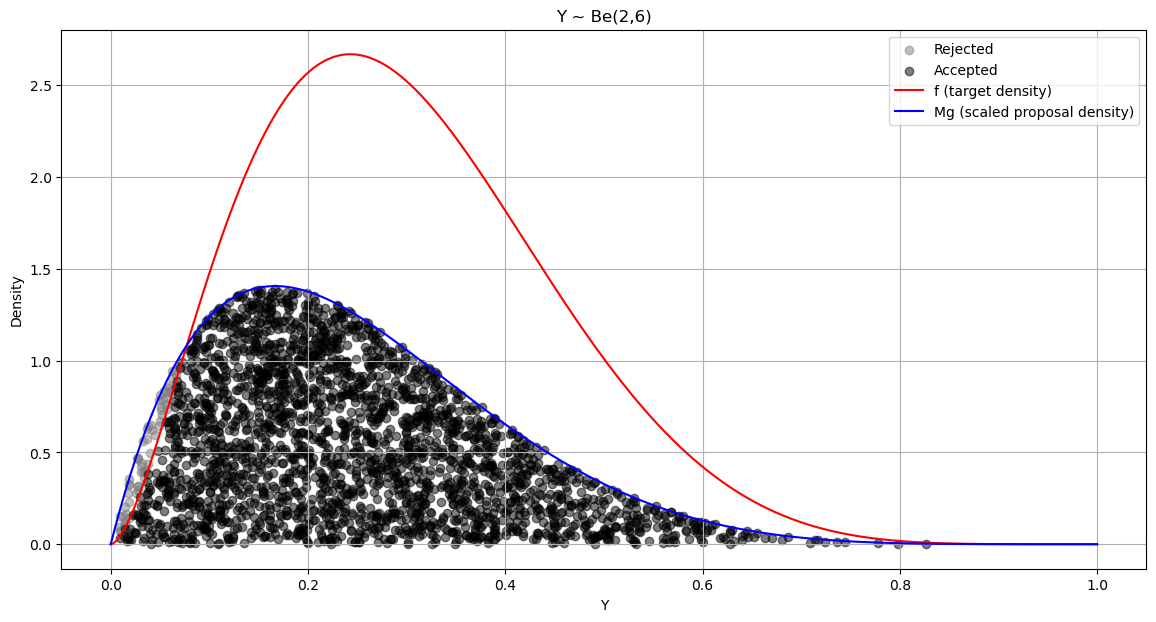

In [2]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, uniform

# Set the parameters for the beta distribution (for the target and proposal distributions)
a_target, b_target = 2.7, 6.3
a_proposal, b_proposal = 2, 6

# Set the number of samples
N = 2500

# Generate samples Y from the proposal distribution Be(2, 6)
Y_proposal = beta.rvs(a_proposal, b_proposal, size=N)

# Generate uniform samples for the Accept-Reject method
U = uniform.rvs(size=N)

# Define the target density function f (Beta distribution)
f = lambda y: beta.pdf(y, a_target, b_target)

# Define the proposal density function g (Beta distribution Be(2, 6))
g = lambda y: beta.pdf(y, a_proposal, b_proposal)

# Calculate the normalization constant M (it's assumed to be 1 for simplicity in this example)
M = 0.5

# Apply the Accept-Reject condition
accepted = U < f(Y_proposal) / (M * g(Y_proposal))

# Calculate the range for plotting the densities
y_values = np.linspace(0, 1, 1000)

# Plot the results
plt.figure(figsize=(14, 7))

# Plot the rejected points
plt.scatter(Y_proposal[~accepted], U[~accepted] * M * g(Y_proposal[~accepted]), color='grey', alpha=0.5, label='Rejected')

# Plot the accepted points
plt.scatter(Y_proposal[accepted], U[accepted] * M * g(Y_proposal[accepted]), color='black', alpha=0.5, label='Accepted')

# Plot the target density f
plt.plot(y_values, f(y_values), 'r-', label='f (target density)')

# Plot the scaled proposal density Mg
plt.plot(y_values, M * g(y_values), 'b-', label='Mg (scaled proposal density)')

# Add titles and labels
plt.title('Y ~ Be(2,6)')
plt.xlabel('Y')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()


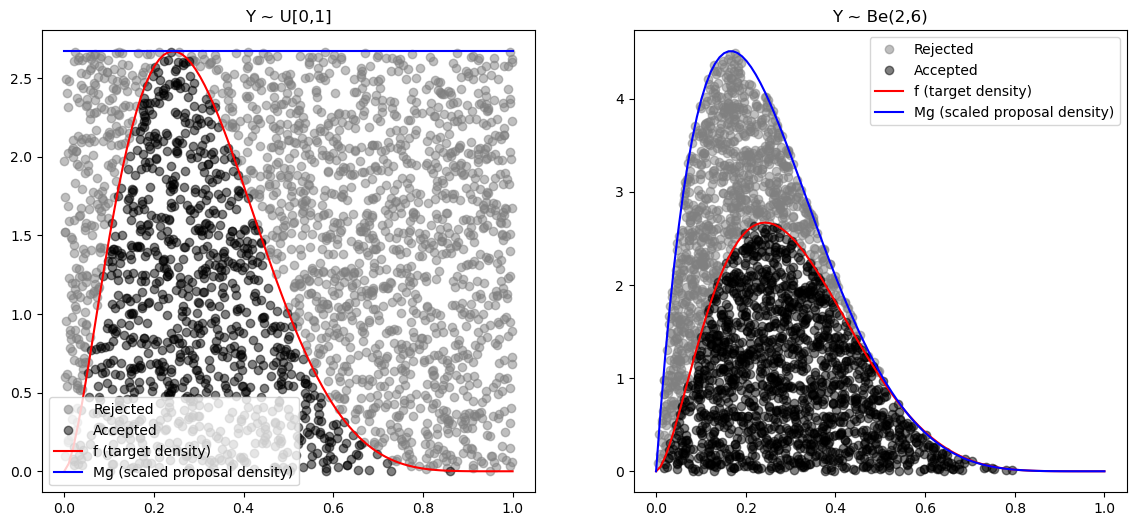

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, uniform

# Parameters for the Beta distribution
a, b = 2.7, 6.3

# Number of proposals
N = 2500

# Generate proposals Y from U[0,1] and Be(2,6) and uniform U from U[0,M]
Y_unif = uniform.rvs(size=N)
Y_beta = beta.rvs(2, 6, size=N)
U = uniform.rvs(scale=1, size=N)  # M is assumed to be 1 for simplicity

# Define the target density f and the proposal density g
f = lambda y: beta.pdf(y, a, b)
g_unif = lambda y: uniform.pdf(y)
g_beta = lambda y: beta.pdf(y, 2, 6)

# Calculate acceptance threshold
M_unif = max(f(np.linspace(0, 1, 1000)) / g_unif(np.linspace(0, 1, 1000)))
M_beta = max(f(np.linspace(0, 1, 1000)) / g_beta(np.linspace(0.01, 0.99, 1000)))

# Determine accepted proposals
accepted_unif = U <= f(Y_unif) / (M_unif * g_unif(Y_unif))
accepted_beta = U <= f(Y_beta) / (M_beta * g_beta(Y_beta))

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: Y ~ U[0,1]
axes[0].plot(Y_unif[~accepted_unif], U[~accepted_unif] * M_unif * g_unif(Y_unif[~accepted_unif]), 'o', color='grey', alpha=0.5, label='Rejected')
axes[0].plot(Y_unif[accepted_unif], U[accepted_unif] * M_unif * g_unif(Y_unif[accepted_unif]), 'o', color='black', alpha=0.5, label='Accepted')
y = np.linspace(0, 1, 100)
axes[0].plot(y, f(y), 'r-', label='f (target density)')
axes[0].plot(y, M_unif * g_unif(y), 'b-', label='Mg (scaled proposal density)')
axes[0].set_title('Y ~ U[0,1]')
axes[0].legend()

# Right panel: Y ~ Be(2,6)
axes[1].plot(Y_beta[~accepted_beta], U[~accepted_beta] * M_beta * g_beta(Y_beta[~accepted_beta]), 'o', color='grey', alpha=0.5, label='Rejected')
axes[1].plot(Y_beta[accepted_beta], U[accepted_beta] * M_beta * g_beta(Y_beta[accepted_beta]), 'o', color='black', alpha=0.5, label='Accepted')
axes[1].plot(y, f(y), 'r-', label='f (target density)')
axes[1].plot(y, M_beta * g_beta(y), 'b-', label='Mg (scaled proposal density)')
axes[1].set_title('Y ~ Be(2,6)')
axes[1].legend()

plt.show()



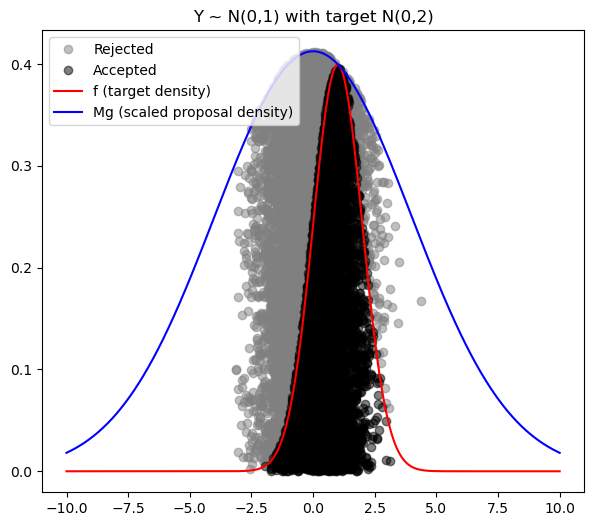

In [9]:
from scipy.stats import norm, uniform
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the target normal distribution
mu, sigma = 0, 2
N = 10000 # Number of proposals

# Generate proposals Y from N(0,1)
Y_norm = norm.rvs(loc=0, scale=1, size=N)
U = uniform.rvs(scale=1, size=N)  # Generate U for acceptance checking

# Define the target and proposal densities
f_norm = lambda y: norm.pdf(y, mu, sigma)
g_norm = lambda y: norm.pdf(y, 0, 4)

# Calculate acceptance threshold for the normal proposal
M_norm = max(f_norm(np.linspace(-10, 10, 1000)) / g_norm(np.linspace(-10, 10, 1000)))

# Determine accepted proposals for the normal proposal
accepted_norm = U <= f_norm(Y_norm) / (M_norm * g_norm(Y_norm))

# Plotting for the normal proposal with all definitions in place
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(Y_norm[~accepted_norm], U[~accepted_norm] * M_norm * g_norm(Y_norm[~accepted_norm]), 'o', color='grey', alpha=0.5, label='Rejected')
ax.plot(Y_norm[accepted_norm], U[accepted_norm] * M_norm * g_norm(Y_norm[accepted_norm]), 'o', color='black', alpha=0.5, label='Accepted')
y = np.linspace(-10, 10, 1000)
ax.plot(y, f_norm(y), 'r-', label='f (target density)')
ax.plot(y, M_norm * g_norm(y), 'b-', label='Mg (scaled proposal density)')
ax.set_title('Y ~ N(0,1) with target N(0,2)')
ax.legend()

plt.show()

